# NextPyper manuscript figures

### Method comparison plotlines

The figure designed for visualising the comparative success of the three selected methods on the simulated data. The figure is meant to be complete and should end up in the supplementary material. A version using stacked bar plot for selected categories shall be used in the body of the manuscript.
This figure depicts the mean and standard variation for selected features across plodies, that is the statistics are derived from all accessions at a given ploidy level. We investigated the methods' performance across various tree depths, that is the influence of the probe/target similarity and several read coverage that would affect the assembly graph construction.

The file structure must consist of a directory (e.g. 'Myears_10_0') that contains all results at a given tree depth. Within it, folders for each coverage (e.g. 'cov_6_allele1') should contain separated results for each method ('Myears_10_0_cov_6_allele1_captus.tsv', 'Myears_10_0_cov_6_allele1_hybpiper.tsv', 'Myears_10_0_cov_6_allele1_nextpyper.tsv').

In [35]:
from pathlib import Path
from dataclasses import dataclass, field
from collections import namedtuple
from statistics import mean, stdev
from typing import Literal

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Headers of the result file
headers=['taxon', 'unique', 'duplicated', 'fragmented', 'missing', 'chimeras_true', 'chimeras_fail']

def get_stdev(lst:list) -> float:
    """
    Compute the standard deviation of a list of numbers. Returns 0 if the list has a single element, otherwise returns the standard deviation.
    """
    if len(lst) == 1:
        return 0
    else:
        return stdev(lst)

ploidy_dict = {'Deca':10, 'Di':2, 'Dodeca':12, 'Hexa':6, 'Octa':8, 'Tetra':4}

def create_table(path:Path)->pd.DataFrame:
    """Fuse the three tables in a new dataframe.
    Sum up the two chimeric categories.
    Add ploidy information from the ploidy_dict."""
    frames = []
    #fuse dataframes, compute chimeras
    for tsv in path.glob('*.tsv'):
        method=tsv.name.split('_')[-1].replace('.tsv','')
        df = pd.read_table(tsv,header=None,names=headers)
        df["chimeras"] = df['chimeras_true'] + df['chimeras_fail']
        df['method'] = method
        frames.append(df)
    concat = pd.concat(frames)
    new_data = []
    for row in concat.itertuples():
        new_row = [row.taxon, row.method, row.unique, row.duplicated, row.fragmented, row.missing, row.chimeras,
                   ploidy_dict[row.taxon.split('_')[0]]]
        new_data.append(new_row)

    return pd.DataFrame(sorted(new_data, key=lambda x:(x[-1], x[0], x[1])), columns=['taxon', 'method', 'unique', 'duplicated', 'fragmented', 'missing', 'chimeras','ploidy'])

def normalize_data(df: pd.DataFrame, probe_number:int) -> pd.DataFrame:
    """Normalize the data across samples to get recovery percentage, get mean and stdev"""
       #compute mean and stdev
    new_data = []
    current_ploidy = None
    method =  None
    unique = []
    duplicated = []
    fragmented = []
    missing = []
    chimeras = []
    sorted_rows = sorted([x for x in df.itertuples()], key=lambda x: (x.method, x.ploidy,))

    for row in sorted_rows:
        ploidy = row.ploidy
        if current_ploidy is None:
            current_ploidy = ploidy
            method = row.method
        if ploidy != current_ploidy:
            new_row = [current_ploidy,method,round(mean(unique),2),round(get_stdev(unique), 2), mean(duplicated),
                       get_stdev(duplicated),mean(fragmented),get_stdev(fragmented),mean(missing),get_stdev(missing),mean(chimeras),get_stdev(chimeras),]
            new_data.append(new_row)
            current_ploidy = ploidy
            method = row.method
            # below the 0.5 value is meant to get the expected number of sequences given the ploidy, i.e. a diploid can only contain a single set of probes.
            unique = [(row.unique / (probe_number*0.5*ploidy))*100]
            duplicated = [(row.duplicated/ (probe_number*0.5*ploidy))*100]
            fragmented = [(row.fragmented/ (probe_number*0.5*ploidy))*100]
            missing = [(row.missing/ (probe_number*0.5*ploidy))*100]
            chimeras = [(row.chimeras/ (probe_number*0.5*ploidy))*100]
        else:
            unique.append((row.unique/ (probe_number*0.5*ploidy))*100)
            duplicated.append((row.duplicated/ (probe_number*0.5*ploidy))*100)
            fragmented.append((row.fragmented/ (probe_number*0.5*ploidy))*100)
            missing.append((row.missing/ (probe_number*0.5*ploidy))*100)
            chimeras.append((row.chimeras/ (probe_number*0.5*ploidy))*100)
    new_row = [current_ploidy,method,round(mean(unique),2),round(get_stdev(unique),2), mean(duplicated),
               get_stdev(duplicated),mean(fragmented),get_stdev(fragmented),mean(missing),get_stdev(missing),mean(chimeras),get_stdev(chimeras),]
    new_data.append(new_row)
    final_df = pd.DataFrame(new_data, columns=['ploidy', 'method', 'unique_mean', 'unique_stdev', 'duplicated_mean', 'duplicated_stdev',
                                               'fragmented_mean', 'fragmented_stdev', 'missing_mean', 'missing_stdev',
                                                'chimeras_mean', 'chimeras_stdev'])
    return final_df

In [48]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

target_year = Path('/home/yjkbertrand/Documents/projects/fumaria_sim/results/Myears_10_0')

years = str(target_year.name).replace('Myears_', "").replace('_','.')
variable_names = ['unique', 'duplicated', 'fragmented', 'chimeras', 'missing']
coverages = [6,10,20,30,50,100]

total_rows = len(coverages)
total_cols = len(variable_names)

fig = make_subplots(rows=total_rows, cols=total_cols, shared_xaxes=True, vertical_spacing=0.02,subplot_titles=variable_names,
                    shared_yaxes=True)

# Adjust layout
fig.update_layout(height=2000, width=1500, title_text=f"Tree depth:{years} M years",
    template="plotly",
    yaxis_range=[0,100], xaxis=dict(
    tickmode = 'array',
    tickvals = [2, 4, 6, 8, 10, 12],
    ticktext = ['0', '4', '6', '8', '10', '12']),
    yaxis=dict(
        title=dict(
            text="% recovered sequences"
        )),
    legend=dict(
            title=dict(
                text="Method"
            )
        ),
    )

# Loop over coverage (rows)
row_col_comb = []
for idx_0, cov in enumerate(coverages):

    row = idx_0 +1
    target = target_year / f"cov_{cov}_allele1"
    # Create df for each allele
    df = create_table(target)
    normal=normalize_data(df, 333)

    # Loop over statistics (columns)
    for idx_1, (mean_val, stdev_val) in enumerate([(f'{var}_mean', f'{var}_stdev') for var in variable_names]):
        col = idx_1 + 1
        legend=True if (idx_0, idx_1) == (0,0) else False
        row_col_comb.append((row, col))
        fig.add_trace(go.Scatter(x=normal[normal['method'] == 'captus']['ploidy'],
        y=normal[normal['method'] == 'captus'][mean_val],
        name='captus', showlegend=legend,
        marker_color='lightsalmon',
        error_y=dict(
        type='data',
        array=normal[normal['method'] == 'captus'][stdev_val],
        visible=True)),
        row=row, col=col)

        fig.add_trace(go.Scatter( x=normal[normal['method'] == 'nextpyper']['ploidy'],
        y=normal[normal['method'] == 'nextpyper'][mean_val],
        name='nextpyper', showlegend=legend,
        marker_color="goldenrod",
        error_y=dict(
        type='data',
        array=normal[normal['method'] == 'nextpyper'][stdev_val],
        visible=True)),
        row=row, col=col)

        fig.add_trace(go.Scatter( x=normal[normal['method'] == 'hybpiper']['ploidy'],
        y=normal[normal['method'] == 'hybpiper'][mean_val],
        name='hybpiper', showlegend=legend,
        marker_color='indianred',
        error_y=dict(
        type='data',
        array=normal[normal['method'] == 'hybpiper'][stdev_val],
        visible=True)),
        row=row, col=col)

# Adjust axes
for (row, col) in row_col_comb:
    if row == len(coverages):
        fig.update_xaxes(title_text="ploidy levels", row=row, col=col, tickmode = 'array', tickvals = [2, 4, 6, 8, 10, 12],
            ticktext = ['2', '4', '6', '8', '10', '12'])
    else:
        fig.update_xaxes(row=row, col=col, tickmode = 'array', tickvals = [2, 4, 6, 8, 10, 12],
            ticktext = ['2', '4', '6', '8', '10', '12'])
    if col == 1:
        fig.update_yaxes(title_text="% recovered sequences", range=[0,100],row=row, col=col)
    elif col == len(variable_names):
        depth = coverages[row-1]
        fig.update_yaxes(title_text=f"coverage {depth}", range=[0,100],row=row, col=col,side="right",)

fig.show()


## Testing python great tables package

In [53]:
from great_tables import GT, html
import polars as pl
import polars.selectors as cs
target_year = Path('/home/yjkbertrand/Documents/projects/fumaria_sim/results/Myears_50_0')

years = str(target_year.name).replace('Myears_', "").replace('_','.')
variable_names = ['unique', 'duplicated', 'fragmented', 'chimeras', 'missing']
coverages = [6,10,20,30,50,100]
method= "captus"
variable = "unique_mean"
# Loop over coverage (rows)

coverage_frames = []
for idx_0, cov in enumerate(coverages):

    row = idx_0 +1
    target = target_year / f"cov_{cov}_allele1"
    # Create df for each allele
    df = create_table(target)
    normal=normalize_data(df, 333)
    normal['coverage'] = cov
    normal[variable] = normal[variable].round(1)
    coverage_frames.append(normal)
all_coverages = pd.concat(coverage_frames)

coverages_pivot = (
    pl.from_pandas(all_coverages)
    .filter((pl.col("method") == method))
    .select(pl.col("*").exclude('unique_stdev', 'duplicated_mean', 'duplicated_stdev',
                                               'fragmented_mean', 'fragmented_stdev', 'missing_mean', 'missing_stdev',
                                                'chimeras_mean', 'chimeras_stdev'))
    .drop_nulls()
    .pivot(values="unique_mean", index="ploidy", on="coverage")
)
print(coverages_pivot)

(
    GT(coverages_pivot, rowname_col="ploidy")

    .data_color(
        domain=[100, 0],
        palette=["green","white","red"],
    )
        .data_color(
        columns=['ploidy'],
        palette=["snow","snow"],
        )
    .tab_header(
        title=f"Unique mean per ploidy at tree depth {years}",
        subtitle=html("."),
    )
    .sub_missing(missing_text="")
)

shape: (6, 7)
┌────────┬──────┬──────┬──────┬──────┬──────┬──────┐
│ ploidy ┆ 6    ┆ 10   ┆ 20   ┆ 30   ┆ 50   ┆ 100  │
│ ---    ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  │
│ i64    ┆ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64  │
╞════════╪══════╪══════╪══════╪══════╪══════╪══════╡
│ 2      ┆ 11.7 ┆ 29.0 ┆ 47.4 ┆ 51.7 ┆ 50.7 ┆ 51.3 │
│ 4      ┆ 11.1 ┆ 29.1 ┆ 49.0 ┆ 50.2 ┆ 51.4 ┆ 50.6 │
│ 6      ┆ 11.6 ┆ 28.8 ┆ 49.2 ┆ 50.8 ┆ 52.1 ┆ 51.4 │
│ 8      ┆ 10.8 ┆ 26.3 ┆ 45.4 ┆ 47.6 ┆ 48.7 ┆ 49.4 │
│ 10     ┆ 11.2 ┆ 28.5 ┆ 48.4 ┆ 50.5 ┆ 51.9 ┆ 50.9 │
│ 12     ┆ 10.3 ┆ 28.9 ┆ 49.8 ┆ 51.7 ┆ 52.6 ┆ 52.5 │
└────────┴──────┴──────┴──────┴──────┴──────┴──────┘


GT(_tbl_data=shape: (6, 7)
┌────────┬──────┬──────┬──────┬──────┬──────┬──────┐
│ ploidy ┆ 6    ┆ 10   ┆ 20   ┆ 30   ┆ 50   ┆ 100  │
│ ---    ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  │
│ i64    ┆ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64  │
╞════════╪══════╪══════╪══════╪══════╪══════╪══════╡
│ 2      ┆ 11.7 ┆ 29.0 ┆ 47.4 ┆ 51.7 ┆ 50.7 ┆ 51.3 │
│ 4      ┆ 11.1 ┆ 29.1 ┆ 49.0 ┆ 50.2 ┆ 51.4 ┆ 50.6 │
│ 6      ┆ 11.6 ┆ 28.8 ┆ 49.2 ┆ 50.8 ┆ 52.1 ┆ 51.4 │
│ 8      ┆ 10.8 ┆ 26.3 ┆ 45.4 ┆ 47.6 ┆ 48.7 ┆ 49.4 │
│ 10     ┆ 11.2 ┆ 28.5 ┆ 48.4 ┆ 50.5 ┆ 51.9 ┆ 50.9 │
│ 12     ┆ 10.3 ┆ 28.9 ┆ 49.8 ┆ 51.7 ┆ 52.6 ┆ 52.5 │
└────────┴──────┴──────┴──────┴──────┴──────┴──────┘, _body=<great_tables._gt_data.Body object at 0x74a9ee23d9f0>, _boxhead=Boxhead([ColInfo(var='ploidy', type=<ColInfoTypeEnum.stub: 2>, column_label='ploidy', column_align='right', column_width=None), ColInfo(var='6', type=<ColInfoTypeEnum.default: 1>, column_label='6', column_align='right', column_width=None), ColInfo(var='10', type=<ColInfoTypeEnum.default: 1>, column_label='10', column_align='right', column_width=None), ColInfo(var='20', type=<ColInfoTypeEnum.default: 1>, column_label='20', column_align='right', column_width=None), ColInfo(var='30', type=<ColInfoTypeEnum.default: 1>, column_label='30', column_align='right', column_width=None), ColInfo(var='50', type=<ColInfoTypeEnum.default: 1>, column_label='50', column_align='right', column_width=None), ColInfo(var='100', type=<ColInfoTypeEnum.default: 1>, column_label='100', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x74a9b8ceb000>, _spanners=Spanners([]), _heading=Heading(title='Unique mean per ploidy at tree depth 50.0', subtitle=Html(text='.'), preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='ploidy', rows=[0], mask=None), grpname=None, colname='ploidy', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ff0a0a')]), StyleInfo(locname=LocBody(columns='ploidy', rows=[1], mask=None), grpname=None, colname='ploidy', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ff1414')]), StyleInfo(locname=LocBody(columns='ploidy', rows=[2], mask=None), grpname=None, colname='ploidy', rownum=2, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ff1f1f')]), StyleInfo(locname=LocBody(columns='ploidy', rows=[3], mask=None), grpname=None, colname='ploidy', rownum=3, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ff2929')]), StyleInfo(locname=LocBody(columns='ploidy', rows=[4], mask=None), grpname=None, colname='ploidy', rownum=4, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ff3333')]), StyleInfo(locname=LocBody(columns='ploidy', rows=[5], mask=None), grpname=None, colname='ploidy', rownum=5, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#ff3d3d')]), StyleInfo(locname=LocBody(columns='6', rows=[0], mask=None), grpname=None, colname='6', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=No

In [69]:
from great_tables import GT, html
import polars as pl
import polars.selectors as cs

year_set = ['0_5','1_0','2_0','3_0','4_0','5_0']
coverages = [6,10,20,30,50,100]
method= "nextpyper"
variable = "unique_mean"
year_cov_comb = []
coverage_frames = []
for year in year_set:
    target_year = Path(f'/home/yjkbertrand/Documents/projects/fumaria_sim/results/Myears_{year}')
    years = str(target_year.name).replace('Myears_', "").replace('_','.')
    for cov in coverages:
        target = target_year / f"cov_{cov}_allele1"
        # Create df for each allele
        df = create_table(target)
        normal=normalize_data(df, 333)
        normal['coverage'] = f"Myears {year}, coverage {cov}"
        year_cov_comb.append(f"Myears {year}, coverage {cov}")
        normal[variable] = normal[variable].round(1)
        coverage_frames.append(normal)
all_coverages = pd.concat(coverage_frames)

coverages_pivot = (
    pl.from_pandas(all_coverages)
    .filter((pl.col("method") == method))
    .select(pl.col("*").exclude('unique_stdev', 'duplicated_mean', 'duplicated_stdev',
                                               'fragmented_mean', 'fragmented_stdev', 'missing_mean', 'missing_stdev',
                                                'chimeras_mean', 'chimeras_stdev'))

    .pivot(values="unique_mean", index="ploidy", on="coverage")
)
print(coverages_pivot)
print(year_cov_comb)
print(list([x for x in year_cov_comb if x.startswith("Myears 10")]))
(
    GT(coverages_pivot, rowname_col="ploidy")

    .data_color(
        domain=[100, 0],
        palette=["green","white","red"],
    )
        .data_color(
        columns=['ploidy'],
        palette=["snow","snow"],
        )
    .tab_spanner(
        label="Myears 0.5",
        columns=list([x for x in year_cov_comb if x.startswith("Myears 0_5")]),
    )
    .tab_header(
        title=f"Unique mean per ploidy at tree depth {years}",
        subtitle=html("."),
    )
    .sub_missing(missing_text="")
    .cols_align(
    align='left',
    columns=['ploidy'])
)

shape: (6, 37)
┌────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ ploidy ┆ Myears     ┆ Myears     ┆ Myears    ┆ … ┆ Myears    ┆ Myears    ┆ Myears    ┆ Myears    │
│ ---    ┆ 0_5,       ┆ 0_5,       ┆ 0_5,      ┆   ┆ 5_0,      ┆ 5_0,      ┆ 5_0,      ┆ 5_0,      │
│ i64    ┆ coverage 6 ┆ coverage   ┆ coverage  ┆   ┆ coverage  ┆ coverage  ┆ coverage  ┆ coverage  │
│        ┆ ---        ┆ 10         ┆ 20        ┆   ┆ 20        ┆ 30        ┆ 50        ┆ 100       │
│        ┆ f64        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│        ┆            ┆ f64        ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2      ┆ 18.4       ┆ 58.2       ┆ 94.8      ┆ … ┆ 95.3      ┆ 97.1      ┆ 97.2      ┆ 97.7      │
│ 4      ┆ 33.5       ┆ 48.1       ┆ 53.7      ┆ … ┆ 81.2      ┆ 87.6      ┆

GT(_tbl_data=shape: (6, 37)
┌────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ ploidy ┆ Myears     ┆ Myears     ┆ Myears    ┆ … ┆ Myears    ┆ Myears    ┆ Myears    ┆ Myears    │
│ ---    ┆ 0_5,       ┆ 0_5,       ┆ 0_5,      ┆   ┆ 5_0,      ┆ 5_0,      ┆ 5_0,      ┆ 5_0,      │
│ i64    ┆ coverage 6 ┆ coverage   ┆ coverage  ┆   ┆ coverage  ┆ coverage  ┆ coverage  ┆ coverage  │
│        ┆ ---        ┆ 10         ┆ 20        ┆   ┆ 20        ┆ 30        ┆ 50        ┆ 100       │
│        ┆ f64        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│        ┆            ┆ f64        ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2      ┆ 18.4       ┆ 58.2       ┆ 94.8      ┆ … ┆ 95.3      ┆ 97.1      ┆ 97.2      ┆ 97.7      │
│ 4      ┆ 33.5       ┆ 48.1       ┆ 53.7      ┆ … ┆ 81.2      ┆ 87.6      ┆ 89.7      ┆ 90.5      │
│ 6      ┆ 30.6       ┆ 35.4       ┆ 38.5      ┆ … ┆ 71.4      ┆ 80.2      ┆ 83.0      ┆ 84.1      │
│ 8      ┆ 25.0       ┆ 27.8       ┆ 29.2      ┆ … ┆ 63.5      ┆ 70.1      ┆ 73.4      ┆ 74.5      │
│ 10     ┆ 20.9       ┆ 24.3       ┆ 27.0      ┆ … ┆ 61.2      ┆ 70.4      ┆ 74.1      ┆ 76.5      │
│ 12     ┆ 19.0       ┆ 19.6       ┆ 21.9      ┆ … ┆ 56.1      ┆ 64.4      ┆ 67.0      ┆ 69.5      │
└────────┴────────────┴────────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x74a9b8a003c0>, _boxhead=Boxhead([ColInfo(var='ploidy', type=<ColInfoTypeEnum.stub: 2>, column_label='ploidy', column_align='left', column_width=None), ColInfo(var='Myears 0_5, coverage 6', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 0_5, coverage 6', column_align='right', column_width=None), ColInfo(var='Myears 0_5, coverage 10', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 0_5, coverage 10', column_align='right', column_width=None), ColInfo(var='Myears 0_5, coverage 20', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 0_5, coverage 20', column_align='right', column_width=None), ColInfo(var='Myears 0_5, coverage 30', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 0_5, coverage 30', column_align='right', column_width=None), ColInfo(var='Myears 0_5, coverage 50', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 0_5, coverage 50', column_align='right', column_width=None), ColInfo(var='Myears 0_5, coverage 100', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 0_5, coverage 100', column_align='right', column_width=None), ColInfo(var='Myears 1_0, coverage 6', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 1_0, coverage 6', column_align='right', column_width=None), ColInfo(var='Myears 1_0, coverage 10', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 1_0, coverage 10', column_align='right', column_width=None), ColInfo(var='Myears 1_0, coverage 20', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 1_0, coverage 20', column_align='right', column_width=None), ColInfo(var='Myears 1_0, coverage 30', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 1_0, coverage 30', column_align='right', column_width=None), ColInfo(var='Myears 1_0, coverage 50', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 1_0, coverage 50', column_align='right', column_width=None), ColInfo(var='Myears 1_0, coverage 100', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 1_0, coverage 100', column_align='right', column_width=None), ColInfo(var='Myears 2_0, coverage 6', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 2_0, coverage 6', column_align='right', column_width=None), ColInfo(var='Myears 2_0, coverage 10', type=<ColInfoTypeEnum.default: 1>, column_label='Myears 2_0, coverage 10', column_align='right', column_width=None), ColInfo(var='Myears 2_0, coverage 20', type=<ColInfoTypeEnum.default: 1>, col

## Creating plots with Wilcoxon test

We wish to create a box plot per method. Each data point would be an alignment and for each ploidy we plot the proportion of recovery.

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Thur vs. Fri: Mann-Whitney-Wilcoxon test two-sided, P_val:6.477e-01 U_stat=6.305e+02
Thur vs. Sat: Mann-Whitney-Wilcoxon test two-sided, P_val:4.690e-02 U_stat=2.180e+03
Sun vs. Fri: Mann-Whitney-Wilcoxon test two-sided, P_val:2.680e-02 U_stat=9.605e+02


(<Axes: xlabel='day', ylabel='total_bill'>,
  <statannotations.Annotation.Annotation at 0x7944bab148f0>])

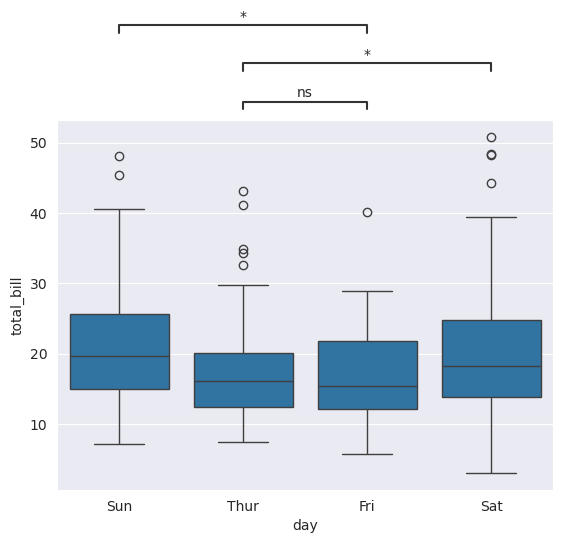

In [5]:
import seaborn as sns

from statannotations.Annotator import Annotator

df = sns.load_dataset("tips")
x = "day"
y = "total_bill"
order = ['Sun', 'Thur', 'Fri', 'Sat']

ax = sns.boxplot(data=df, x=x, y=y, order=order)

pairs=[("Thur", "Fri"), ("Thur", "Sat"), ("Fri", "Sun")]

annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
annotator.apply_and_annotate()

In [24]:
from pathlib import Path
from dataclasses import dataclass, field
from collections import namedtuple
from statistics import mean, stdev
from typing import Literal

import pandas as pd

# Headers of the result file
headers=['taxon', 'unique', 'duplicated', 'fragmented', 'missing', 'chimeras_true', 'chimeras_fail']

def get_stdev(lst:list) -> float:
    """
    Compute the standard deviation of a list of numbers. Returns 0 if the list has a single element, otherwise returns the standard deviation.
    """
    if len(lst) == 1:
        return 0
    else:
        return stdev(lst)

ploidy_dict = {'Deca':10, 'Di':2, 'Dodeca':12, 'Hexa':6, 'Octa':8, 'Tetra':4}

def create_table(path:Path)->pd.DataFrame:
    """Fuse the three tables in a new dataframe.
    Sum up the two chimeric categories.
    Add ploidy information from the ploidy_dict."""
    frames = []
    #fuse dataframes, compute chimeras
    for tsv in path.glob('*.tsv'):
        method=tsv.name.split('_')[-1].replace('.tsv','')
        df = pd.read_table(tsv,header=None,names=headers)
        df["chimeras"] = df['chimeras_true'] + df['chimeras_fail']
        df['method'] = method
        frames.append(df)
    concat = pd.concat(frames)
    new_data = []
    for row in concat.itertuples():
        new_row = [row.taxon, row.method, row.unique, row.duplicated, row.fragmented, row.missing, row.chimeras,
                   ploidy_dict[row.taxon.split('_')[0]]]
        new_data.append(new_row)

    return pd.DataFrame(sorted(new_data, key=lambda x:(x[-1], x[0], x[1])), columns=['taxon', 'method', 'unique', 'duplicated', 'fragmented', 'missing', 'chimeras','ploidy'])

def normalize_data_sample(df: pd.DataFrame, probe_number:int) -> pd.DataFrame:
    """Normalize the data per samples to get recovery percentage"""
    new_data = []
    sorted_rows = sorted([x for x in df.itertuples()], key=lambda x: (x.method, x.ploidy,))
    for row in sorted_rows:
        ploidy = row.ploidy
        def get_percent(cell:int)->float:
            return round(cell*100 / (probe_number*0.5*ploidy), 2)
        new_row = [ploidy,row.taxon,row.method,get_percent(row.unique), get_percent(row.duplicated),get_percent(row.fragmented),get_percent(row.chimeras),get_percent(row.missing),]
        new_data.append(new_row)
    final_df = pd.DataFrame(new_data, columns=['ploidy', 'taxon','method', 'unique',  'duplicated','fragmented', 'missing','chimeras', ])
    return final_df


In [32]:
target_year = Path('/home/yjkbertrand/Documents/projects/fumaria_sim/results/Myears_10_0')
cov = 100
years = str(target_year.name).replace('Myears_', "").replace('_','.')
target = target_year / f"cov_{cov}_allele1"
df = create_table(target)
norm_df = normalize_data_sample(df, 333)
norm_df

,ploidy,taxon,method,unique,duplicated,fragmented,missing,chimeras
0,2,Di_A_10_0,captus,99.70,0.00,0.0,0.00,0.30
1,2,Di_B_10_0,captus,99.70,0.00,0.0,0.00,0.30
2,2,Di_C_10_0,captus,99.70,0.00,0.0,0.00,0.30
3,2,Di_D_10_0,captus,99.70,0.00,0.0,0.00,0.30
4,2,Di_E_10_0,captus,99.70,0.00,0.0,0.00,0.30
...,...,...,...,...,...,...,...,...
103,8,Octa_C_10_0,nextpyper,79.95,2.18,0.0,5.56,12.31
104,10,Deca_A_10_0,nextpyper,95.50,0.00,0.0,0.48,4.02
105,10,Deca_B_10_0,nextpyper,96.04,0.00,0.0,0.12,3.84
106,10,Deca_C_10_0,nextpyper,90.39,0.06,0.0,3.60,5.95


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

nextpyper vs. captus: Mann-Whitney-Wilcoxon test two-sided, P_val:3.917e-03 U_stat=9.045e+02
captus vs. hybpiper: Mann-Whitney-Wilcoxon test two-sided, P_val:2.961e-13 U_stat=1.296e+03
nextpyper vs. hybpiper: Mann-Whitney-Wilcoxon test two-sided, P_val:3.019e-13 U_stat=1.296e+03


(<Axes: xlabel='method', ylabel='unique'>,
  <statannotations.Annotation.Annotation at 0x79444d552d50>])

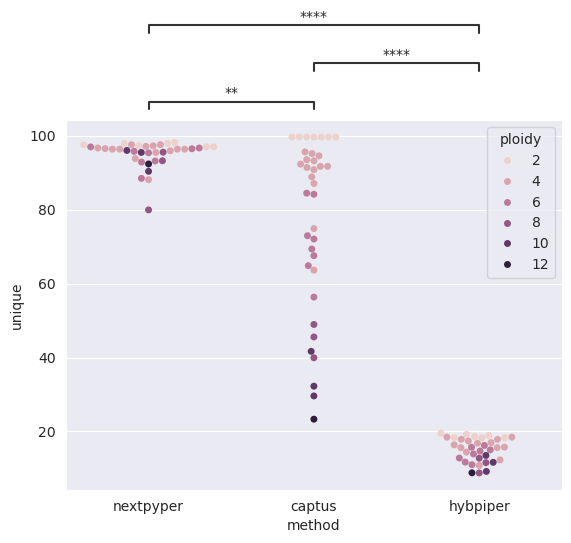

In [37]:
x = "method"
y = "unique"
order = ['nextpyper','captus', 'hybpiper']
# ax = sns.violinplot(data=norm_df, x=x, y=y, order=order)
ax = sns.swarmplot(data=norm_df, x=x, y=y, order=order, hue="ploidy")
pairs=[('nextpyper','captus'), ('nextpyper', 'hybpiper'), ('captus', 'hybpiper')]
annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
annotator.apply_and_annotate()